In [ ]:
import pandas as pd
df = pd.read_csv('/content/bengaluru_house_prices.csv')

# EDA

In [ ]:
df.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [ ]:
df.nunique()

,0
area_type,4
availability,81
location,1305
size,31
society,2688
total_sqft,2117
bath,19
balcony,4
price,1994


# Preprocessing

Null values

In [ ]:
# drop society bec > 40% missing and mostly unique values (no pattern can be concluded -> the model can not benifit from it)
df = df.drop('society', axis=1)
df = df.dropna(subset=['location', 'size']) #drop the rows with null values of size and location ->around 20 rows

# bath balcony: numeric with a narrow range so median can be used to fill the missing values
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

It is noticed that total_sqft appered as an object rather than integer

as illustreated in the cell bellow it  contains ranges and units suffixes that needs to be converted to nnumeric values

In [ ]:
# check what total sqft looks like before cleaning
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

non_numeric = df[~df['total_sqft'].apply(is_float)]
print(non_numeric.shape[0], "non-numeric total_sqft values found")
non_numeric['total_sqft'].head(20)

239 non-numeric total_sqft values found


,total_sqft
30,2100 - 2850
56,3010 - 3410
81,2957 - 3450
122,3067 - 8156
137,1042 - 1105
165,1145 - 1340
188,1015 - 1540
224,1520 - 1740
410,34.46Sq. Meter
549,1195 - 1440


Cleaning function that takes the mean of ranges and remove the units

In [ ]:
import re

def convert_sqft(x):
    x = str(x).strip()

    # Case 1: range like "2100 - 2850"  so take the average
    if '-' in x:
        parts = x.split('-')
        try:
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except:
            return None

    # case 2:plain number
    try:
        return float(x)
    except:
        pass

    # case 3: has unit suffix -> convert to sqft
    match = re.match(r"([\d.]+)\s*(\w+\.?\s?\w*)", x)
    if match:
        value = float(match.group(1))
        unit = match.group(2).lower().replace(' ', '').replace('.', '')

        conversions = {
            'sqmeter': 10.7639,
            'sqyards': 9.0,
            'perch': 272.25,
            'acres': 43560.0,
            'cents': 435.6,
            'guntha': 1089.0,
            'grounds': 2400.35,
        }
        for key, factor in conversions.items():
            if key in unit:
                return value * factor

    return None  # couldn't parse

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

# check how many failed to parse
print(df['total_sqft'].isnull().sum())

0


Also the column size contain units and words -> but we only need to extract the numbers

size ->> bhk  extract the numeric bedroom count

also we drop the outliers that we found in baths and bhk

In [ ]:
df['bhk'] = df['size'].apply(lambda x: int(str(x).split(' ')[0]))
df = df.drop('size', axis=1)
df = df[df['bhk'] <= 10]

# bath max was 40 vs a median of 2 -> same kind of data entry error
df = df[df['bath'] <= 10]

location column cleaning — strip stray leading digits (a side effect of the same data corruption above), then group rare locations (<10 listings) into `other` to avoid a huge sparse one-hot encoding.

In [ ]:
df['location'] = df['location'].apply(lambda x: re.sub(r'^\d+\s*', '', str(x)).strip())

location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts < 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

prices outliers handling

In [ ]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
df = df[(df['price_per_sqft'] >= 500) & (df['price_per_sqft'] <= 40000)]
df = df.drop('price_per_sqft', axis=1)

# Encoding
availability : ready-now (0) vs not (1)
area_type and location that were grouped earlier are one hot encoded

In [ ]:
df['availability'] = df['availability'].apply(lambda x: 1 if x == 'Ready To Move' else 0)
df = df.rename(columns={'availability': 'is_ready_to_move'})

df = pd.get_dummies(df, columns=['area_type', 'location'], drop_first=True)

# Data splitting

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1)).ravel()

# Building the FCNN (regression)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

learning_rate = 0.0005

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.summary()

model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=['mae']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 32)             │         8,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,897 (34.75 KB)

 Trainable params: 8,897 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

# Model training

In [ ]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3903 - mae: 0.6731 - val_loss: 0.8338 - val_mae: 0.4259
Epoch 2/200
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9156 - mae: 0.4984 - val_loss: 0.6578 - val_mae: 0.3540
Epoch 3/200
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7629 - mae: 0.4482 - val_loss: 0.5751 - val_mae: 0.3087
Epoch 4/200
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6711 - mae: 0.4183 - val_loss: 0.5327 - val_mae: 0.2904
Epoch 5/200
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6367 - mae: 0.3906 - val_loss: 0.5096 - val_mae: 0.2864
Epoch 6/200
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5542 - mae: 0.3700 - val_loss: 0.4883 - val_mae: 0.2748
Epoch 7/200
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5676 - mae: 0.3546 - val_loss: 0.4708 - val_mae: 0.2705
Epoch 8/200
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5051 - mae: 0.3386 - val_loss: 0.4716 - val_mae: 0.2659
Epoch 9/200
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

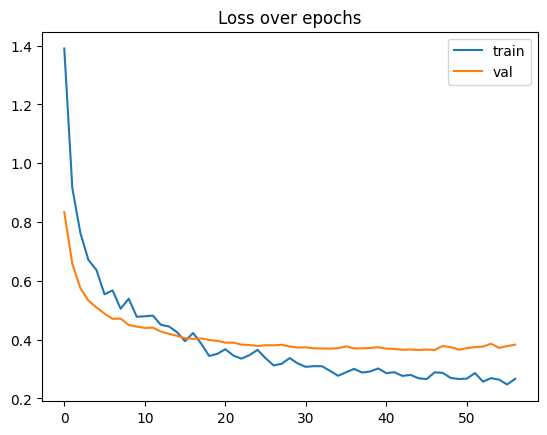

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.title('Loss over epochs')
plt.show()

# Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_scaled = model.predict(X_test_scaled).ravel()
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} ")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.3f}")

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE:  32.35 
RMSE: 66.55
R2:   0.730


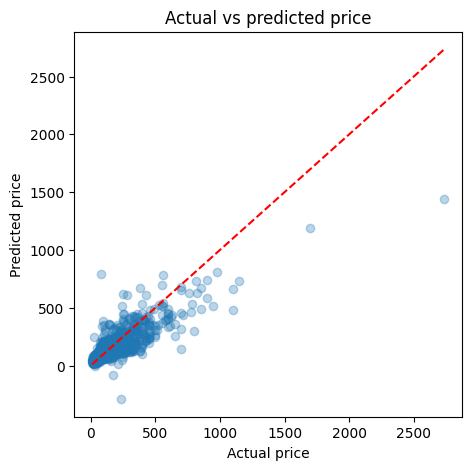

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs predicted price')
plt.show()